# Recopilación y preparación de datos
## Modelo de riesgo de default crediticio — Lending Club
**Ciencia de Datos Aplicada · ITBA · Segundo entregable**

Gianluca Giannine Lizarraga · Timoteo Harrington · Lucas Kim

Este notebook retoma la propuesta presentada en el Entregable 01: estimar la probabilidad de default (PD) de un solicitante de préstamo a partir de información disponible al momento de la solicitud, traducirla en bandas de riesgo, y estimar una prima de riesgo de default (PD × LGD) para cada solicitante.

**Contenido de este entregable:**
1. Descripción del dataset
2. Tipos de variables y calidad de los datos
3. Construcción de la variable objetivo
4. Análisis exploratorio inicial (sobre el dataset completo)
5. Clasificación de variables: ex-ante vs. ex-post (data leakage)
6. Split temporal train/test
7. Análisis exploratorio sobre train (post-split)
8. Cálculo empírico de LGD
9. Transformaciones y dataset final para modelado
10. Reflexión final


## 1. Descripción del dataset

**Origen:** Lending Club, plataforma estadounidense de préstamos peer-to-peer. Los datos corresponden a préstamos originados entre 2007 y 2011, publicados originalmente por Lending Club y distribuidos como parte de un dataset de referencia ampliamente utilizado en cursos de ciencia de datos aplicada a riesgo crediticio.

**Formato:** un archivo CSV, una fila por préstamo, con 111 columnas que incluyen información del solicitante al momento de la solicitud (variables demográficas, laborales, de historial crediticio) y del desempeño del préstamo a lo largo de su vida (pagos, recuperos, estado).

**Justificación de la elección:** el dataset permite plantear un problema de clasificación binaria con variable objetivo limpia (`loan_status`: Fully Paid vs. Charged Off), separación clara entre información disponible ex-ante y ex-post, y suficientes variables financieras y crediticias para construir un modelo de riesgo con sentido de negocio. Es además un dataset de referencia en la literatura de *credit scoring*, lo que permite comparar resultados contra trabajos existentes.

**Nota sobre la versión utilizada:** existen múltiples versiones del dataset de Lending Club en circulación (desde ~40.000 hasta ~2.26 millones de préstamos, cubriendo distintas ventanas 2007-2018). En este entregable trabajamos con la versión de 2007-2011 (~40.000 préstamos), que es manejable en un entorno de cómputo estándar y, al concentrar observaciones en años previos y posteriores a la crisis financiera de 2008, permite además observar directamente el efecto del ciclo económico sobre la tasa de default — un punto que habíamos identificado como relevante para el análisis (ver Sección 7).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/loan.csv', low_memory=False)
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")


Filas: 39,717
Columnas: 111


In [2]:
df.head(3)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,...,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,real estate business,606xx,IL,8.72,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


## 2. Tipos de variables y calidad de los datos

Antes de cualquier análisis, revisamos los tipos de datos, la proporción de valores faltantes por columna y la presencia de duplicados.


In [3]:
dtype_counts = df.dtypes.value_counts()
print("Tipos de datos:")
print(dtype_counts)
print()
n_numeric = df.select_dtypes(include=[np.number]).shape[1]
n_object = df.select_dtypes(include=['object']).shape[1]
print(f"Variables numéricas: {n_numeric}")
print(f"Variables de texto/categóricas: {n_object}")


Tipos de datos:
float64    74
str        24
int64      13
Name: count, dtype: int64

Variables numéricas: 87
Variables de texto/categóricas: 24


/tmp/ipykernel_200/1247612392.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  n_object = df.select_dtypes(include=['object']).shape[1]


In [4]:
# Duplicados
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"IDs duplicados: {df['id'].duplicated().sum()}")


Filas duplicadas: 0
IDs duplicados: 0


In [5]:
# Missing values por columna
missing = df.isna().mean().sort_values(ascending=False) * 100
missing_summary = missing[missing > 0].reset_index()
missing_summary.columns = ['variable', 'pct_missing']
print(f"Columnas con al menos un valor faltante: {len(missing_summary)} de {df.shape[1]}")
print()
print("Columnas con 100% de valores faltantes (no reportadas en 2007-2011):")
print(missing_summary[missing_summary['pct_missing'] == 100.0]['variable'].tolist())


Columnas con al menos un valor faltante: 68 de 111

Columnas con 100% de valores faltantes (no reportadas en 2007-2011):
['num_il_tl', 'num_bc_sats', 'num_bc_tl', 'num_actv_bc_tl', 'num_accts_ever_120_pd', 'mths_since_recent_revol_delinq', 'num_actv_rev_tl', 'mths_since_recent_inq', 'num_tl_90g_dpd_24m', 'num_tl_30dpd', 'num_tl_120dpd_2m', 'num_sats', 'num_rev_tl_bal_gt_0', 'num_rev_accts', 'pct_tl_nvr_dlq', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mths_since_recent_bc', 'mort_acc', 'mths_since_recent_bc_dlq', 'bc_util', 'total_rev_hi_lim', 'all_util', 'bc_open_to_buy', 'avg_cur_bal', 'acc_open_past_24mths', 'inq_last_12m', 'total_cu_tl', 'inq_fi', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'open_il_6m', 'open_il_24m', 'verification_status_joint', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_12m', 'annual_inc_joint', 'dti_joint', 'mths_since_last_major_derog', 'total_bc_limit', 

**Diagnóstico:** un grupo grande de columnas (~40) está 100% vacío en esta ventana temporal — son variables de historial crediticio más detallado (`mths_since_recent_bc`, `num_actv_rev_tl`, `total_bc_limit`, etc.) que Lending Club empezó a reportar recién en años posteriores a 2011. Esto confirma algo que habíamos anticipado en la propuesta: el dataset tiene **missing no aleatorio por período**, no aleatorio dentro de una misma cosecha. Estas columnas se descartan directamente, no se imputan.


In [6]:
# Descartamos columnas 100% vacías
cols_vacias = missing_summary[missing_summary['pct_missing'] == 100.0]['variable'].tolist()
df = df.drop(columns=cols_vacias)
print(f"Columnas restantes tras descartar las 100% vacías: {df.shape[1]}")

# Missing parcial remanente (top 15)
missing_parcial = df.isna().mean().sort_values(ascending=False) * 100
missing_parcial = missing_parcial[missing_parcial > 0]
print()
print("Top variables con missing parcial:")
print(missing_parcial.head(15).round(1))


Columnas restantes tras descartar las 100% vacías: 57

Top variables con missing parcial:
next_pymnt_d                  97.1
mths_since_last_record        93.0
mths_since_last_delinq        64.7
desc                          32.6
emp_title                      6.2
emp_length                     2.7
pub_rec_bankruptcies           1.8
last_pymnt_d                   0.2
collections_12_mths_ex_med     0.1
chargeoff_within_12_mths       0.1
revol_util                     0.1
tax_liens                      0.1
title                          0.0
last_credit_pull_d             0.0
dtype: float64


Las columnas con missing parcial alto (`mths_since_last_record`, `mths_since_last_delinq`, `mths_since_last_major_derog`) representan "meses desde el último registro público / mora / derogación" — el valor faltante en estos casos **no es un dato perdido, es informativo**: significa que el solicitante nunca tuvo ese evento. Se trata en la Sección 9 (Transformaciones), no se imputa con la media.


## 3. Construcción de la variable objetivo

`loan_status` es la variable de la que se deriva el target. Revisamos sus categorías antes de definir el binario.


In [7]:
print(df['loan_status'].value_counts())
print()
print(df['loan_status'].value_counts(normalize=True).round(3) * 100)


loan_status
Fully Paid     32950
Charged Off     5627
Current         1140
Name: count, dtype: int64

loan_status
Fully Paid     83.0
Charged Off    14.2
Current         2.9
Name: proportion, dtype: float64


**Decisión:** seguimos el criterio estándar en la literatura de *granting models*: nos quedamos únicamente con préstamos en estado **Fully Paid** (pagado en su totalidad) o **Charged Off** (incumplido), y descartamos los que están **Current** (en curso) porque todavía no sabemos si van a terminar pagando o no — incluirlos introduciría censura por maduración, tal como habíamos anticipado en la propuesta.


In [8]:
df_model = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df_model['default'] = (df_model['loan_status'] == 'Charged Off').astype(int)

print(f"Préstamos excluidos (Current): {(df['loan_status'] == 'Current').sum()}")
print(f"Préstamos en el dataset de modelado: {df_model.shape[0]:,}")
print()
print("Distribución del target:")
print(df_model['default'].value_counts())
print(f"Tasa de default: {df_model['default'].mean():.2%}")


Préstamos excluidos (Current): 1140
Préstamos en el dataset de modelado: 38,577

Distribución del target:
default
0    32950
1     5627
Name: count, dtype: int64
Tasa de default: 14.59%


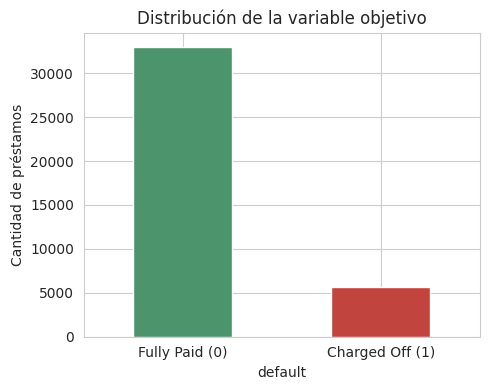

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
df_model['default'].value_counts().sort_index().plot(
    kind='bar', color=['#4C956C', '#C1443E'], ax=ax
)
ax.set_xticklabels(['Fully Paid (0)', 'Charged Off (1)'], rotation=0)
ax.set_ylabel('Cantidad de préstamos')
ax.set_title('Distribución de la variable objetivo')
plt.tight_layout()
plt.savefig('../notebooks/fig_target_distribution.png', dpi=120)
plt.show()


**Lectura:** la tasa de default en esta muestra es de aproximadamente 14.5% — un desbalance moderado, no extremo, que se puede manejar con *class weights* en el modelado sin necesidad de *undersampling* agresivo.


## 4. Análisis exploratorio inicial (sobre el dataset completo)

Antes de hacer el split temporal, hacemos un primer pantallazo general del dataset completo — distribuciones, outliers y estadísticas descriptivas a nivel global. El análisis exploratorio *enfocado en relación con el target* se hace después del split (Sección 7), usando solo el conjunto de entrenamiento, para no contaminar la evaluación con información del período de test.


In [10]:
num_cols_interes = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'revol_util', 'open_acc', 'total_acc']
df_model[num_cols_interes].describe().round(2)


,loan_amnt,installment,annual_inc,dti,open_acc,total_acc
count,38577.00,38577.00,38577.00,38577.00,38577.00,38577.00
mean,11047.03,322.47,68777.97,13.27,9.28,22.05
std,7348.44,208.64,64218.68,6.67,4.40,11.43
min,500.00,15.69,4000.00,0.00,2.00,2.00
25%,5300.00,165.74,40000.00,8.13,6.00,13.00
50%,9600.00,277.86,58868.00,13.37,9.00,20.00
75%,15000.00,425.55,82000.00,18.56,12.00,29.00
max,35000.00,1305.19,6000000.00,29.99,44.00,90.00


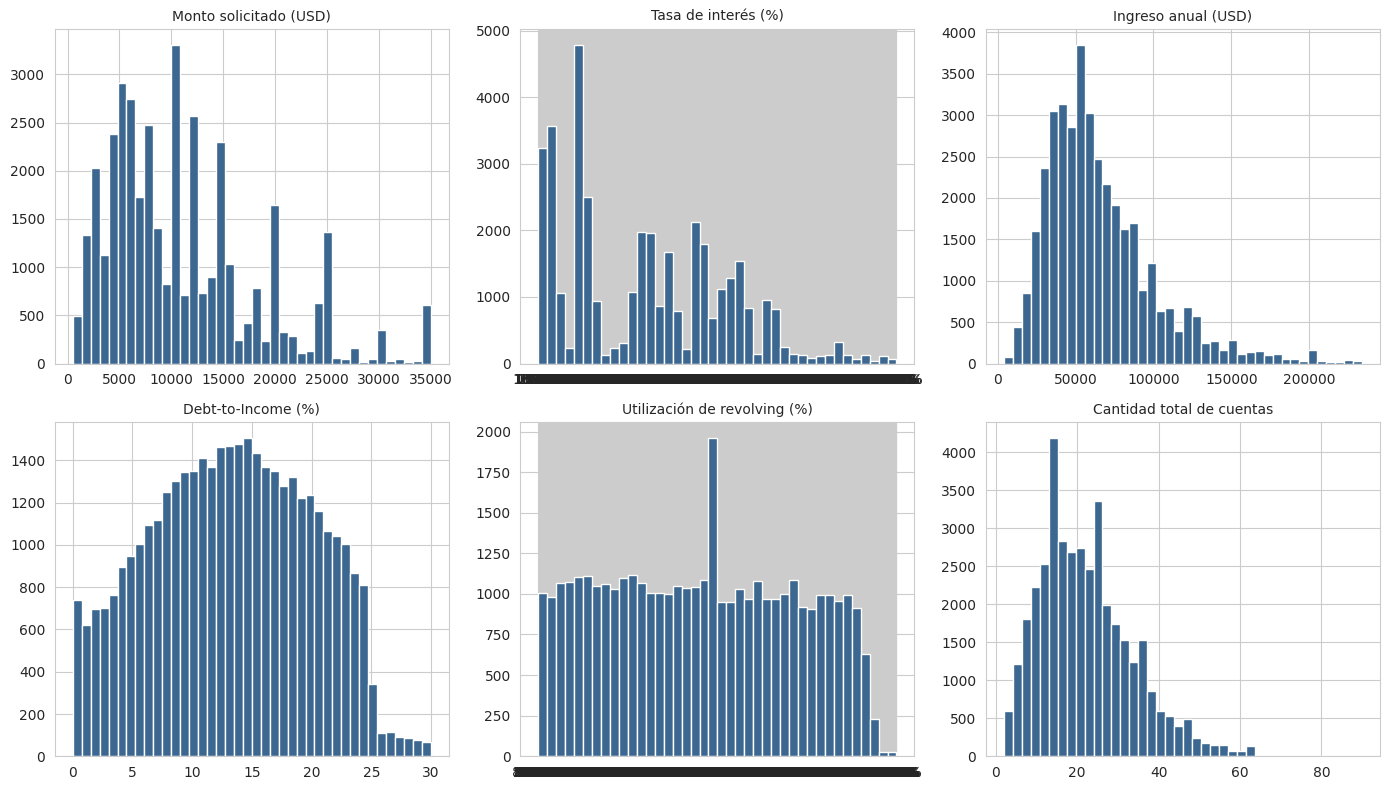

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_util', 'total_acc']
titles = ['Monto solicitado (USD)', 'Tasa de interés (%)', 'Ingreso anual (USD)',
          'Debt-to-Income (%)', 'Utilización de revolving (%)', 'Cantidad total de cuentas']

for ax, col, title in zip(axes.flat, plot_cols, titles):
    data = df_model[col].dropna()
    if col == 'annual_inc':
        data = data[data < data.quantile(0.99)]  # recortamos outliers extremos solo para visualizar
    ax.hist(data, bins=40, color='#3B6790', edgecolor='white')
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.savefig('../notebooks/fig_distribuciones.png', dpi=120)
plt.show()


**Outliers observados:**
- `annual_inc` tiene una cola derecha muy larga (algunos solicitantes reportan ingresos de varios millones) — se recorta al percentil 99 solo para visualización, no se elimina del dataset (podría ser información real y relevante para el modelo).
- `dti` y `revol_util` tienen valores por encima de rangos típicos (dti > 100 en algunos casos), lo cual amerita revisión en la Sección 9.
- `int_rate` y `loan_amnt` no muestran outliers preocupantes — distribuciones razonables sin valores imposibles.


In [12]:
# Chequeo puntual de valores fuera de rango razonable
print("dti > 100:", (df_model['dti'] > 100).sum())
print("annual_inc == 0:", (df_model['annual_inc'] == 0).sum())
print("annual_inc > 1,000,000:", (df_model['annual_inc'] > 1_000_000).sum())
print("loan_amnt <= 0:", (df_model['loan_amnt'] <= 0).sum())


dti > 100: 0
annual_inc == 0: 0
annual_inc > 1,000,000: 14
loan_amnt <= 0: 0


## 5. Clasificación de variables: ex-ante vs. ex-post (data leakage)

Este es el paso metodológico más importante del entregable. Clasificamos cada variable según si estaría disponible **al momento de otorgar el préstamo** (ex-ante, utilizable para el modelo) o si solo existe **después de otorgado** (ex-post, debe excluirse por leakage).


In [13]:
EX_ANTE = [
    # Préstamo solicitado
    'loan_amnt', 'funded_amnt', 'term',
    # Solicitante — laboral / demográfico
    'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'purpose', 'title', 'zip_code', 'addr_state',
    # Historial crediticio (buró, disponible al momento de la solicitud)
    'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
    'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
    'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'initial_list_status', 'application_type',
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'mths_since_last_major_derog', 'acc_now_delinq',
    # Metadata de fecha (no es feature del modelo, se usa para el split)
    'issue_d',
]

# Ambiguas: fijadas por el propio modelo interno de riesgo de Lending Club.
# Están disponibles ex-ante en sentido estricto, pero usarlas es "aprender
# de otro modelo de riesgo" en vez de aprender de las características crudas
# del solicitante. Se excluyen del modelo principal y se usan solo como
# benchmark de comparación (grade/sub_grade) contra nuestras propias bandas.
AMBIGUAS_ENDOGENAS = ['grade', 'sub_grade', 'int_rate', 'installment']

EX_POST = [
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'collections_12_mths_ex_med', 'pymnt_plan',
]

# Identificadores / texto libre / no informativos para el modelo
DESCARTAR = ['id', 'member_id', 'url', 'desc', 'policy_code']

TARGET = ['loan_status', 'default']

# Chequeo: toda columna del dataset está clasificada en alguna categoría
todas_clasificadas = set(EX_ANTE + AMBIGUAS_ENDOGENAS + EX_POST + DESCARTAR + TARGET)
sin_clasificar = set(df_model.columns) - todas_clasificadas
print(f"Variables ex-ante: {len(EX_ANTE)}")
print(f"Variables ambiguas (endógenas al scoring de LC): {len(AMBIGUAS_ENDOGENAS)}")
print(f"Variables ex-post (leakage, se excluyen): {len(EX_POST)}")
print(f"Descartadas (identificadores/texto libre): {len(DESCARTAR)}")
print(f"Sin clasificar: {len(sin_clasificar)} -> {sin_clasificar}")


Variables ex-ante: 31
Variables ambiguas (endógenas al scoring de LC): 4
Variables ex-post (leakage, se excluyen): 15
Descartadas (identificadores/texto libre): 5
Sin clasificar: 5 -> {'delinq_amnt', 'chargeoff_within_12_mths', 'pub_rec_bankruptcies', 'funded_amnt_inv', 'tax_liens'}


**Sobre el caso ambiguo (`grade`, `sub_grade`, `int_rate`, `installment`):** estas variables sí están disponibles al momento de otorgar el préstamo — pero son el **output del propio modelo de riesgo de Lending Club**, no características crudas del solicitante. Usarlas como feature de entrada sería, en los hechos, entrenar un modelo que aprende a imitar a otro modelo de riesgo en vez de aprender de la información real del solicitante. Por eso se excluyen del modelo principal y se reservan para la Sección 7, donde se comparan contra las bandas de riesgo propias como benchmark de la industria (`grade` de Lending Club vs. bandas propias, tal como se planteó en el Entregable 01).

**`recoveries` y `collection_recovery_fee`** se excluyen del modelo de PD, pero se **usan en la Sección 8** para calcular el LGD empírico — ahí sí es correcto usarlos, porque el cálculo de LGD se hace sobre préstamos ya resueltos (históricos), no como input de un modelo que predice sobre solicitudes nuevas.


## 6. Split temporal train/test

Antes de continuar con el EDA enfocado en el target, separamos train y test **por fecha de originación** (`issue_d`), no de forma aleatoria. El test set representa préstamos más recientes — el "futuro" desde la perspectiva del modelo — lo cual es más realista que un split aleatorio y evita que el EDA posterior "mire" información del período que después se usa para evaluar.


In [14]:
df_model['issue_d_parsed'] = pd.to_datetime(df_model['issue_d'], format='%b-%y')
df_model['issue_year'] = df_model['issue_d_parsed'].dt.year

print("Préstamos por año de originación:")
print(df_model['issue_year'].value_counts().sort_index())


Préstamos por año de originación:
issue_year
2007      251
2008     1562
2009     4716
2010    11532
2011    20516
Name: count, dtype: int64


In [15]:
# Split temporal: los últimos ~20% de meses por fecha van a test
df_model = df_model.sort_values('issue_d_parsed').reset_index(drop=True)
corte = df_model['issue_d_parsed'].quantile(0.8)

train = df_model[df_model['issue_d_parsed'] <= corte].copy()
test = df_model[df_model['issue_d_parsed'] > corte].copy()

print(f"Fecha de corte: {corte.date()}")
print(f"Train: {train.shape[0]:,} préstamos ({train['issue_d_parsed'].min().date()} a {train['issue_d_parsed'].max().date()})")
print(f"Test:  {test.shape[0]:,} préstamos ({test['issue_d_parsed'].min().date()} a {test['issue_d_parsed'].max().date()})")
print()
print(f"Tasa de default train: {train['default'].mean():.2%}")
print(f"Tasa de default test:  {test['default'].mean():.2%}")


Fecha de corte: 2011-09-01
Train: 32,532 préstamos (2007-06-01 a 2011-09-01)
Test:  6,045 préstamos (2011-10-01 a 2011-12-01)

Tasa de default train: 14.02%
Tasa de default test:  17.63%


A partir de acá, **todo el análisis exploratorio y las decisiones de preprocesamiento se calibran sobre `train`**. El `test` queda apartado y solo se va a tocar en el entregable de modelado (Entrega 03) para evaluar.


## 7. Análisis exploratorio sobre train (post-split)

Con el split ya hecho, exploramos cómo se relacionan las variables ex-ante con el default, usando solo `train`.


In [16]:
default_por_year = train.groupby('issue_year')['default'].agg(['mean', 'count'])
default_por_year.columns = ['tasa_default', 'cantidad_prestamos']
print(default_por_year.round(3))


            tasa_default  cantidad_prestamos
issue_year                                  
2007               0.179                 251
2008               0.158                1562
2009               0.126                4716
2010               0.129               11532
2011               0.151               14471


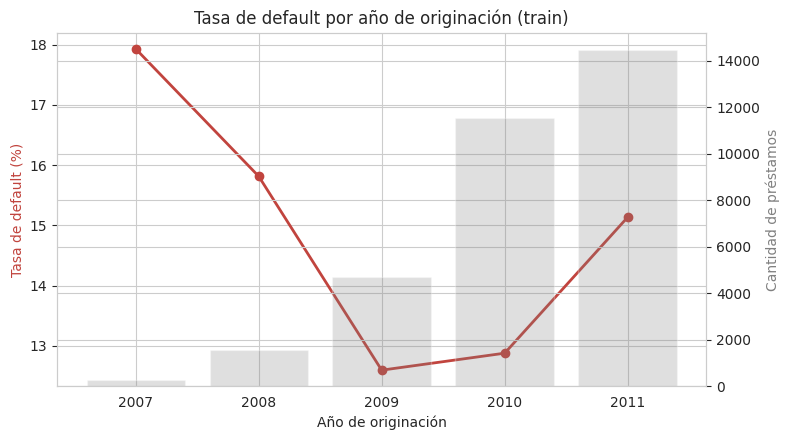

In [17]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax2 = ax1.twinx()

ax2.bar(default_por_year.index, default_por_year['cantidad_prestamos'],
        alpha=0.25, color='gray', label='Cantidad de préstamos')
ax1.plot(default_por_year.index, default_por_year['tasa_default'] * 100,
         marker='o', color='#C1443E', linewidth=2, label='Tasa de default')

ax1.set_xlabel('Año de originación')
ax1.set_ylabel('Tasa de default (%)', color='#C1443E')
ax2.set_ylabel('Cantidad de préstamos', color='gray')
ax1.set_title('Tasa de default por año de originación (train)')
plt.tight_layout()
plt.savefig('../notebooks/fig_default_por_year.png', dpi=120)
plt.show()


**Hallazgo clave:** se observa exactamente el patrón anticipado en la propuesta — las cosechas de 2007-2008 (crisis financiera) tienen una tasa de default notablemente más alta que las cosechas posteriores, aunque representan pocas observaciones frente al total. Esto es evidencia empírica directa del efecto procíclico de la PD (la probabilidad de default sube en contextos macroeconómicos adversos, no solo por peores características individuales de los solicitantes), y confirma que el modelo que entrenemos va a ser **through-the-cycle** (TTC) por construcción, ya que mezcla cosechas de distintos momentos del ciclo sin ajustar por ello — limitación que dejamos documentada para la Sección 10.


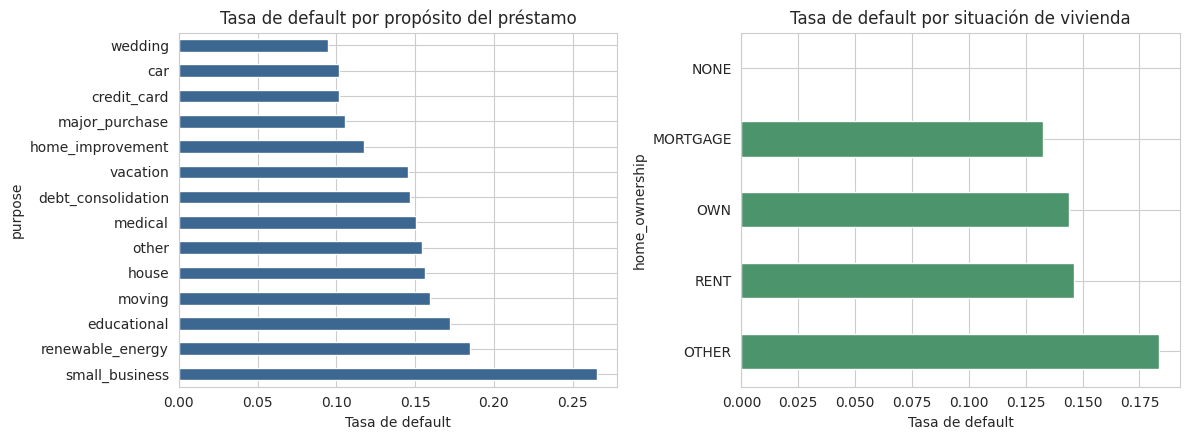

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

default_por_purpose = train.groupby('purpose')['default'].mean().sort_values(ascending=False)
default_por_purpose.plot(kind='barh', ax=axes[0], color='#3B6790')
axes[0].set_title('Tasa de default por propósito del préstamo')
axes[0].set_xlabel('Tasa de default')

default_por_home = train.groupby('home_ownership')['default'].mean().sort_values(ascending=False)
default_por_home.plot(kind='barh', ax=axes[1], color='#4C956C')
axes[1].set_title('Tasa de default por situación de vivienda')
axes[1].set_xlabel('Tasa de default')

plt.tight_layout()
plt.savefig('../notebooks/fig_default_categoricas.png', dpi=120)
plt.show()


In [19]:
# DTI y default
train['dti_bin'] = pd.qcut(train['dti'], q=5, duplicates='drop')
default_por_dti = train.groupby('dti_bin', observed=True)['default'].mean()
print("Tasa de default por quintil de DTI:")
print(default_por_dti.round(3))


Tasa de default por quintil de DTI:
dti_bin
(-0.001, 6.73]    0.121
(6.73, 11.18]     0.126
(11.18, 15.13]    0.143
(15.13, 19.6]     0.151
(19.6, 29.99]     0.160
Name: default, dtype: float64


**Lectura:** el propósito del préstamo y la situación de vivienda muestran diferencias claras en tasa de default (`small_business` y `renewable_energy` destacan como más riesgosos; `RENT` supera a `MORTGAGE`/`OWN`), y el DTI muestra una relación creciente y razonablemente monótona con el default — buena señal de que es una variable con poder predictivo real, consistente con lo esperado desde la teoría de riesgo crediticio.


## 8. Cálculo empírico de LGD

Calculamos el LGD (*Loss Given Default*) empíricamente, sobre los préstamos de `train` que efectivamente entraron en default (`Charged Off`), usando la porción del monto financiado que no se recuperó.


In [20]:
charged_off = train[train['default'] == 1].copy()

# LGD = 1 - (lo recuperado / lo expuesto)
# Lo recuperado incluye tanto el principal cobrado antes del charge-off
# como las recuperaciones posteriores (recoveries), menos el costo de cobranza.
charged_off['recuperado_total'] = (
    charged_off['total_rec_prncp'] + charged_off['recoveries'] - charged_off['collection_recovery_fee']
)
charged_off['lgd'] = 1 - (charged_off['recuperado_total'] / charged_off['funded_amnt'])
charged_off['lgd'] = charged_off['lgd'].clip(0, 1)  # acotamos a [0,1] por consistencia económica

print(f"Préstamos en default (train): {charged_off.shape[0]:,}")
print(f"LGD promedio empírico: {charged_off['lgd'].mean():.2%}")
print(f"LGD mediana: {charged_off['lgd'].median():.2%}")
print()
print(charged_off['lgd'].describe().round(3))


Préstamos en default (train): 4,561
LGD promedio empírico: 59.57%
LGD mediana: 64.10%

count    4561.000
mean        0.596
std         0.255
min         0.000
25%         0.401
50%         0.641
75%         0.812
max         1.000
Name: lgd, dtype: float64


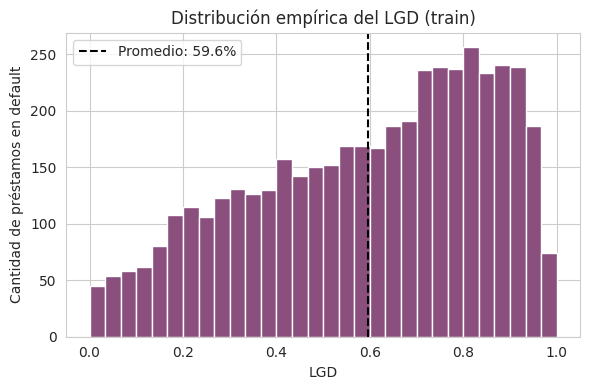

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(charged_off['lgd'], bins=30, color='#8A4F7D', edgecolor='white')
ax.axvline(charged_off['lgd'].mean(), color='black', linestyle='--', label=f"Promedio: {charged_off['lgd'].mean():.1%}")
ax.set_xlabel('LGD')
ax.set_ylabel('Cantidad de préstamos en default')
ax.set_title('Distribución empírica del LGD (train)')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/fig_lgd_distribucion.png', dpi=120)
plt.show()


**Lectura:** tal como se anticipó en la propuesta, la distribución de LGD **no es normal** — se concentra fuertemente cerca de valores altos (pérdida casi total) con algo de masa en valores bajos, más parecida a una forma bimodal/asimétrica que a una campana simétrica. Para el pricing simplificado (Entrega 04), se utiliza el **promedio muestral** como valor fijo, documentando explícitamente que esto subestima la dispersión real del recupero — es una simplificación consciente, no un desconocimiento de la forma real de la distribución.

Este valor de LGD promedio calculado arriba es el que se usará más adelante junto con la PD estimada por el modelo para calcular la prima de riesgo: **Prima ≈ PD × LGD**.


## 9. Transformaciones

Preparamos el dataset final de variables ex-ante para el modelado (Entrega 03): codificación de variables categóricas, generación de nuevas variables, y filtrado a las columnas relevantes.


In [22]:
# Algunas variables de EX_ANTE (annual_inc_joint, dti_joint, etc.) fueron
# descartadas en la Sección 2 por estar 100% vacías en esta ventana temporal.
# Filtramos la lista a las columnas que efectivamente existen en el dataframe.
ex_ante_disponibles = [c for c in EX_ANTE if c in train.columns]
descartadas_por_missing_total = [c for c in EX_ANTE if c not in train.columns]
print(f"Variables ex-ante disponibles en esta ventana: {len(ex_ante_disponibles)}")
print(f"Excluidas por estar 100% vacías en 2007-2011: {descartadas_por_missing_total}")

df_features = train[ex_ante_disponibles].copy()

# --- emp_length: texto -> numérico ---
emp_length_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10
}
df_features['emp_length_num'] = df_features['emp_length'].map(emp_length_map)
print("emp_length antes:", train['emp_length'].value_counts(dropna=False).head())


Variables ex-ante disponibles en esta ventana: 27
Excluidas por estar 100% vacías en 2007-2011: ['annual_inc_joint', 'dti_joint', 'verification_status_joint', 'mths_since_last_major_derog']
emp_length antes: emp_length
10+ years    7017
< 1 year     3959
2 years      3689
3 years      3468
4 years      2843
Name: count, dtype: int64


In [23]:
# --- term: '36 months' -> 36 (numérico) ---
df_features['term_meses'] = df_features['term'].str.extract(r'(\d+)').astype(float)

# --- earliest_cr_line: antigüedad crediticia en años al momento del préstamo ---
df_features['earliest_cr_line_parsed'] = pd.to_datetime(train['earliest_cr_line'], format='%b-%y')
df_features['antiguedad_crediticia_anios'] = (
    (train['issue_d_parsed'] - df_features['earliest_cr_line_parsed']).dt.days / 365.25
)

# --- mths_since_last_delinq / mths_since_last_record: el missing ES informativo ---
# En vez de imputar con la media, creamos un flag "nunca tuvo el evento" y
# dejamos el valor numérico solo donde sí ocurrió.
if 'mths_since_last_delinq' in train.columns:
    df_features['tuvo_delincuencia_previa'] = train['mths_since_last_delinq'].notna().astype(int)
if 'mths_since_last_record' in train.columns:
    df_features['tuvo_registro_publico_previo'] = train['mths_since_last_record'].notna().astype(int)

# --- log de ingreso anual (distribución muy sesgada, ver Sección 4) ---
df_features['log_annual_inc'] = np.log1p(df_features['annual_inc'])

print("Nuevas variables creadas: emp_length_num, term_meses, antiguedad_crediticia_anios,")
print("tuvo_delincuencia_previa, tuvo_registro_publico_previo, log_annual_inc")


Nuevas variables creadas: emp_length_num, term_meses, antiguedad_crediticia_anios,
tuvo_delincuencia_previa, tuvo_registro_publico_previo, log_annual_inc


In [24]:
# --- Codificación de variables categóricas ---
categoricas_nominales = ['home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status']
cols_a_dropear = ['emp_length', 'term', 'earliest_cr_line_parsed', 'title', 'zip_code', 'emp_title',
                  'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'issue_d']
cols_a_dropear = [c for c in cols_a_dropear if c in df_features.columns]

df_features_encoded = pd.get_dummies(
    df_features.drop(columns=cols_a_dropear),
    columns=[c for c in categoricas_nominales if c in df_features.columns],
    drop_first=True
)

print(f"Shape antes de encoding: {df_features.shape}")
print(f"Shape después de encoding: {df_features_encoded.shape}")


Shape antes de encoding: (32532, 34)
Shape después de encoding: (32532, 90)


**Decisiones de encoding:**
- `home_ownership`, `verification_status`, `purpose`, `addr_state`, `initial_list_status`: sin orden natural entre categorías -> **one-hot encoding**.
- `emp_length`: sí tiene orden natural (0 a 10+ años) -> se mapea a **numérico ordinal**, no a dummies.
- `emp_title`, `title`, `zip_code`: texto libre / alta cardinalidad sin estructura clara -> se descartan por ahora (podrían revisarse para feature engineering adicional, ej. agrupar `emp_title` por sector).
- `annual_inc_joint`, `dti_joint`, `verification_status_joint`: 100% missing en este dataset (no hay solicitudes conjuntas en 2007-2011) -> se descartan por falta de variabilidad.


In [25]:
# Variables con más de 50% de missing tras el encoding (para revisar en Entrega 03)
missing_final = df_features_encoded.isna().mean().sort_values(ascending=False)
print("Variables con missing remanente:")
print(missing_final[missing_final > 0].round(3))


Variables con missing remanente:
mths_since_last_record    0.923
mths_since_last_delinq    0.638
emp_length_num            0.025
revol_util                0.001
dtype: float64


In [26]:
df_features_encoded.to_csv('../data/train_features_ex_ante.csv', index=False)
print(f"Dataset final de features guardado: {df_features_encoded.shape[0]:,} filas x {df_features_encoded.shape[1]} columnas")
print(f"Archivo: data/train_features_ex_ante.csv")


Dataset final de features guardado: 32,532 filas x 90 columnas
Archivo: data/train_features_ex_ante.csv


## 10. Reflexión final

**Decisiones tomadas y justificación:**
- Se usó la versión 2007-2011 del dataset de Lending Club (~40.000 préstamos), en vez del dataset completo 2007-2018 (~2.26M), por ser manejable en un entorno de cómputo estándar y por permitir observar directamente el efecto del ciclo económico (crisis 2008) dentro de la ventana de datos.
- El target se construyó filtrando únicamente `Fully Paid` y `Charged Off`, descartando préstamos `Current` para evitar censura por maduración.
- El split train/test se hizo **temporal**, no aleatorio, y **antes** del EDA enfocado en el target, para evitar contaminar el análisis con información del período de evaluación.
- Se clasificaron explícitamente las variables en ex-ante, ex-post y "ambiguas endógenas" (`grade`, `sub_grade`, `int_rate`, `installment`), dejando estas últimas fuera del modelo principal pero reservadas como benchmark.
- El LGD se calculó empíricamente sobre los préstamos en default de train, confirmando que su distribución no es normal (tal como se había anticipado).

**Dificultades encontradas:**
- Un bloque grande de columnas (~40) está 100% vacío en esta ventana temporal, porque Lending Club empezó a reportarlas recién en años posteriores — hubo que verificarlo columna por columna antes de decidir qué descartar.
- Los missing en `mths_since_last_delinq` y `mths_since_last_record` no son missing "real" sino informativos (ausencia del evento), lo cual requirió un tratamiento distinto al de imputación estándar.
- El parseo de fechas (`issue_d`, `earliest_cr_line`) requirió atención al formato específico (`%b-%y`) para poder calcular antigüedad crediticia y hacer el split temporal correctamente.

**Próximos pasos (Entrega 03):**
- Entrenar Logistic Regression (baseline), Random Forest y Gradient Boosting sobre `train`, evaluando en `test`.
- Evaluar con ROC-AUC, PR-AUC, matriz de confusión y KS statistic — no solo accuracy.
- Comparar el poder discriminante del modelo contra el `grade`/`sub_grade` de Lending Club (benchmark de industria).
- Construir las bandas de riesgo (percentiles del score) y validar que la tasa de default real observada por banda sea claramente creciente.
- Con las bandas armadas, calcular la prima de riesgo por banda (PD × LGD) tal como se planteó en el Entregable 01.
